<a href="https://colab.research.google.com/github/harshakurada/Intelligent-Cyber-Threat-Detection-Using-Machine-Learning/blob/main/intel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn plotly joblib

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import joblib

import warnings
warnings.filterwarnings("ignore")

In [3]:
url = "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTrain%2B.txt"

df = pd.read_csv(
    url,
    header=None
)

print(df.shape)
df.head()

(125973, 43)


,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [4]:
columns = [
'duration','protocol_type','service','flag','src_bytes',
'dst_bytes','land','wrong_fragment','urgent','hot',
'num_failed_logins','logged_in','num_compromised',
'root_shell','su_attempted','num_root',
'num_file_creations','num_shells','num_access_files',
'num_outbound_cmds','is_host_login','is_guest_login',
'count','srv_count','serror_rate','srv_serror_rate',
'rerror_rate','srv_rerror_rate','same_srv_rate',
'diff_srv_rate','srv_diff_host_rate','dst_host_count',
'dst_host_srv_count','dst_host_same_srv_rate',
'dst_host_diff_srv_rate',
'dst_host_same_src_port_rate',
'dst_host_srv_diff_host_rate',
'dst_host_serror_rate',
'dst_host_srv_serror_rate',
'dst_host_rerror_rate',
'dst_host_srv_rerror_rate',
'label',
'difficulty'
]

df.columns = columns

df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [5]:
df['label'] = df['label'].apply(
    lambda x: 0 if x == 'normal' else 1
)

print(df['label'].value_counts())

label
0    67343
1    58630
Name: count, dtype: int64


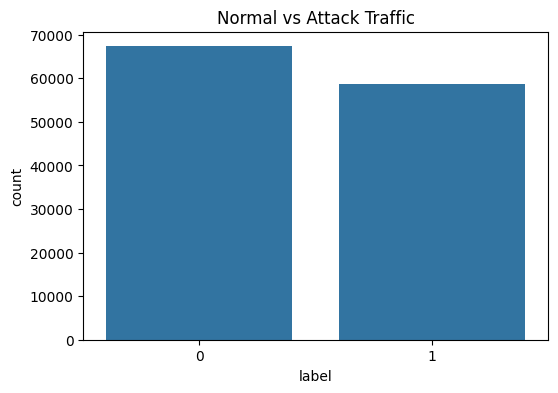

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=df['label']
)

plt.title("Normal vs Attack Traffic")

plt.show()

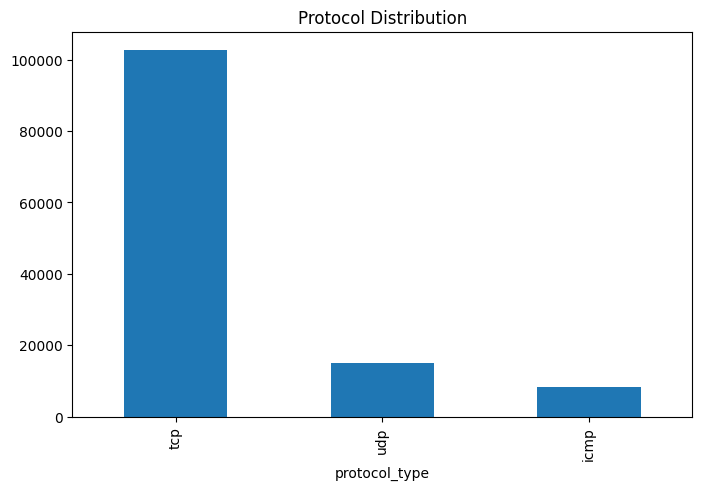

In [7]:
plt.figure(figsize=(8,5))

df['protocol_type'].value_counts().plot(
    kind='bar'
)

plt.title("Protocol Distribution")

plt.show()

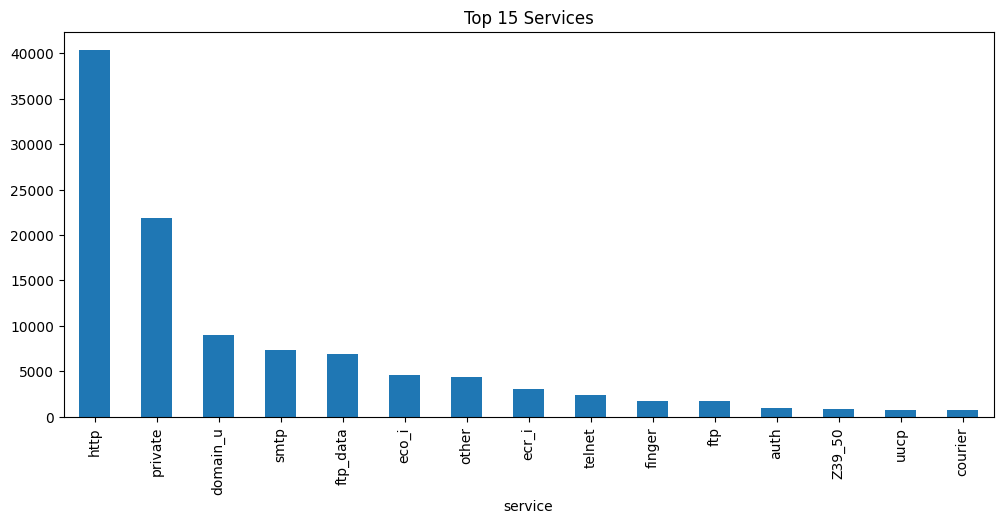

In [8]:
plt.figure(figsize=(12,5))

df['service'].value_counts()[:15].plot(
    kind='bar'
)

plt.title("Top 15 Services")

plt.show()

In [9]:
df = pd.get_dummies(
    df,
    columns=[
        'protocol_type',
        'service',
        'flag'
    ]
)

print(df.shape)

(125973, 124)


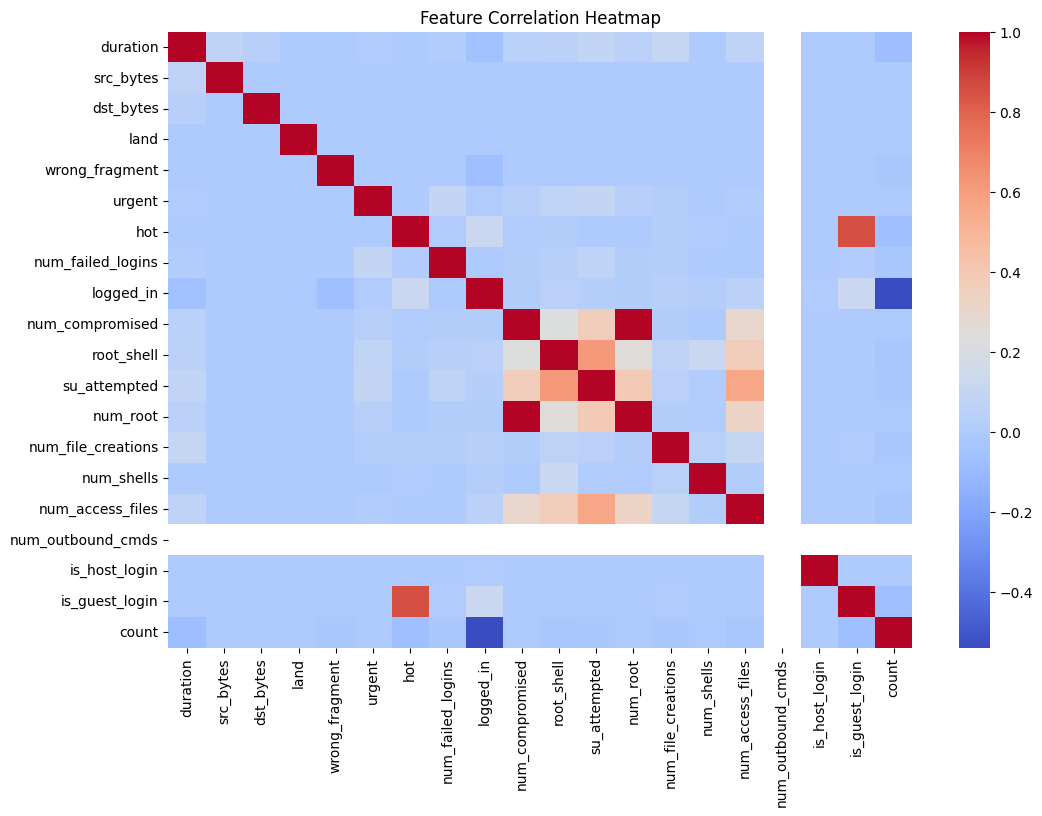

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.iloc[:, :20].corr(),
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [11]:
X = df.drop(
    ['label','difficulty'],
    axis=1
)

y = df['label']

print(X.shape)
print(y.shape)

(125973, 122)
(125973,)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(100778, 122)
(25195, 122)


In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

In [14]:
print(X_train.shape)
print(y_train.value_counts())

(100778, 122)
label
0    53874
1    46904
Name: count, dtype: int64


In [15]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        )
}

In [16]:
results = []

trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    prob = model.predict_proba(X_test)[:,1]

    results.append({

        "Model": name,

        "Accuracy":
            accuracy_score(y_test, pred),

        "Precision":
            precision_score(y_test, pred),

        "Recall":
            recall_score(y_test, pred),

        "F1 Score":
            f1_score(y_test, pred),

        "ROC AUC":
            roc_auc_score(y_test, prob)
    })

    trained_models[name] = model

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...


In [17]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,Random Forest,0.998968,0.999402,0.998380,0.998891,0.999994
1,Decision Tree,0.998452,0.998040,0.998636,0.998338,0.998464
3,Gradient Boosting,0.996150,0.995991,0.995736,0.995863,0.999782
0,Logistic Regression,0.972296,0.976660,0.963500,0.970035,0.996323


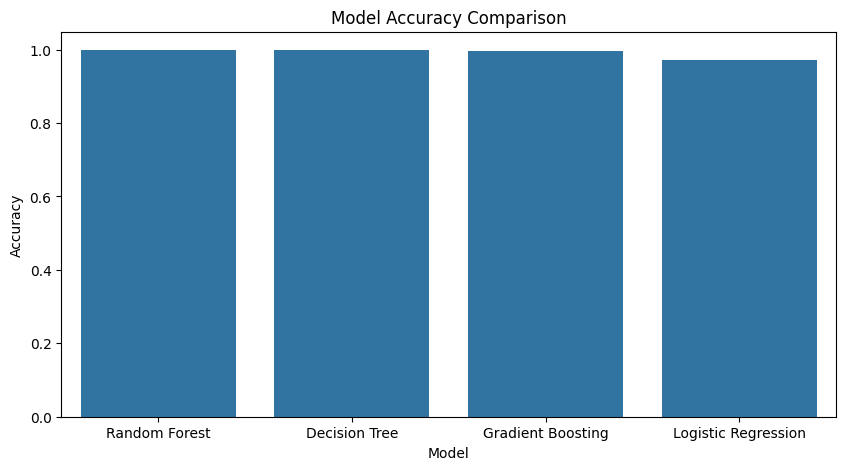

In [18]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title(
    "Model Accuracy Comparison"
)

plt.show()

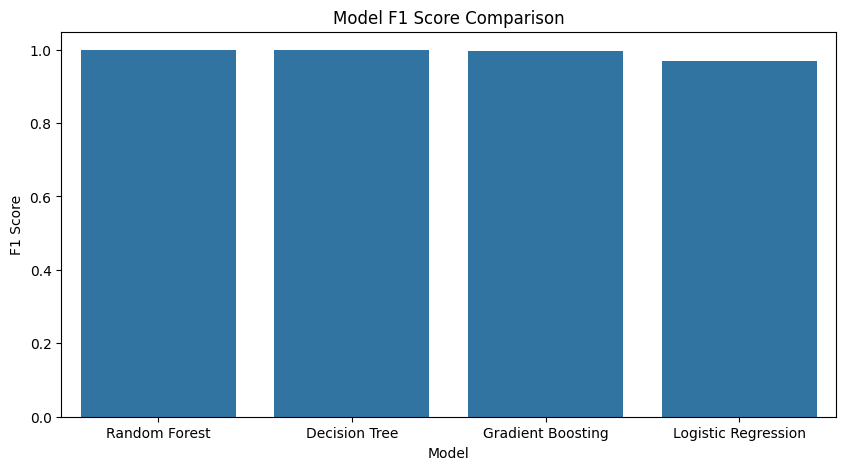

In [19]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1 Score"
)

plt.title(
    "Model F1 Score Comparison"
)

plt.show()

In [20]:
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]

print(
    "Best Model:",
    best_model_name
)

Best Model: Random Forest


In [21]:
feature_names = X.columns
importance_df = pd.DataFrame({

    "Feature":
        feature_names,

    "Importance":
        best_model.feature_importances_
})
importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
1,src_bytes,0.150879
120,flag_SF,0.082093
2,dst_bytes,0.081333
8,logged_in,0.064416
30,dst_host_same_srv_rate,0.062897
29,dst_host_srv_count,0.055734
25,same_srv_rate,0.052708
35,dst_host_srv_serror_rate,0.040237
26,diff_srv_rate,0.040128
38,protocol_type_icmp,0.031164


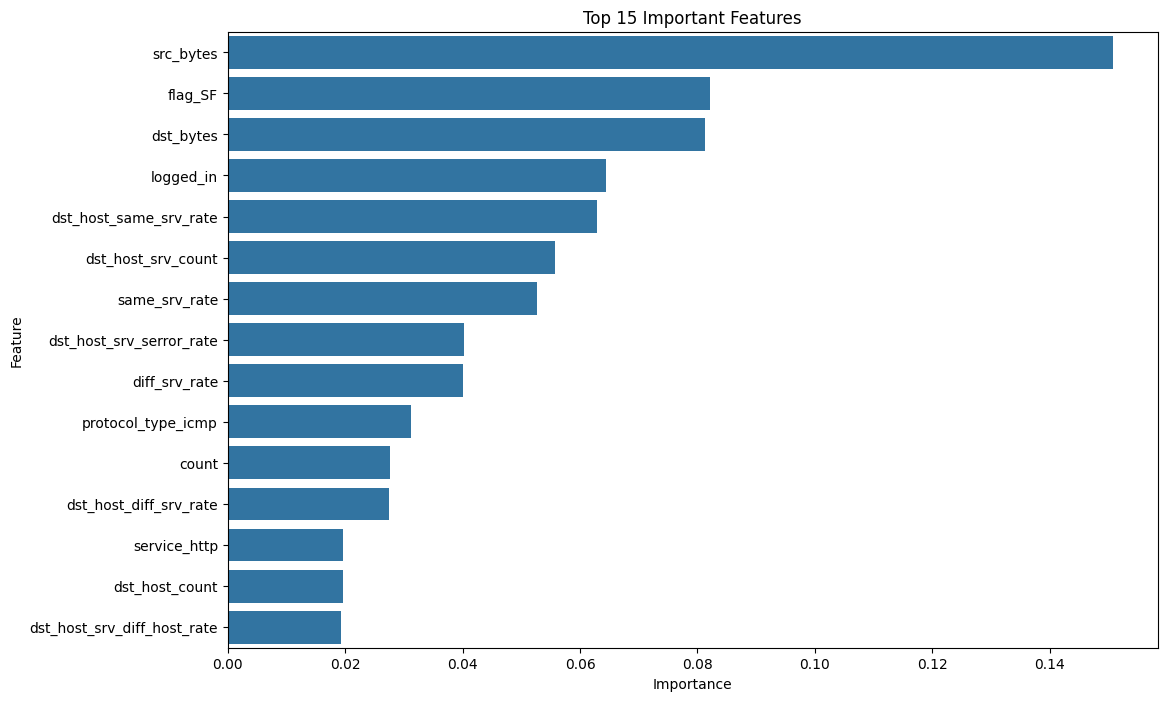

In [22]:
plt.figure(figsize=(12,8))

sns.barplot(

    data=importance_df.head(15),

    x="Importance",

    y="Feature"
)

plt.title(
    "Top 15 Important Features"
)

plt.show()

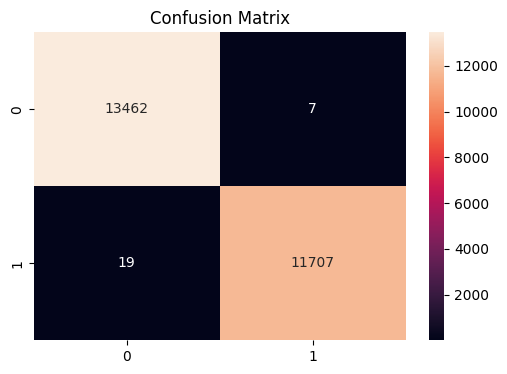

In [23]:
pred = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "Confusion Matrix"
)

plt.show()

In [24]:
import joblib

joblib.dump(
    best_model,
    "model.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

joblib.dump(
    feature_names.tolist(),
    "columns.pkl"
)

joblib.dump(
    importance_df,
    "feature_importance.pkl"
)

print("All Files Saved Successfully")

All Files Saved Successfully


In [25]:
from google.colab import files

files.download("model.pkl")
files.download("scaler.pkl")
files.download("columns.pkl")
files.download("feature_importance.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>